In [1]:
import vcf
import gzip
import sys,os
import pandas as pd
import allel
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
?allel.read_vcf

In [3]:
#chrom = "LR880645.1" # chromosome 1
chrom = "LR880651.1" # chromosome 7
start = 0
end = 5000000
callset = allel.read_vcf('Quare.LG7.vcf.gz', region="{}:{}-{}".format(chrom, start, end))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


In [5]:
total_list = []
for i in callset['calldata/GT']:
    tmp_list = []
    for x in i:
        tmp_list.append(sum(x))
    total_list.append(tmp_list)

In [7]:
callset['samples']

array(['QuH-F12', 'QuH-F13', 'QuH-F21', 'QuH-F22', 'QuH-F25', 'QuH-F3',
       'QuH-F4', 'QuH-F6', 'QuH-F7', 'QuH-F9', 'QuH-M10', 'QuH-M13',
       'QuH-M17', 'QuH-M19', 'QuH-M22', 'QuH-M2', 'QuH-M3', 'QUH-M4',
       'QUH-M9', 'QuL-F11', 'QuL-F14', 'QuL-F15', 'QUL-F16', 'QuL-F19',
       'QuL-F23', 'QuL-F4', 'QUL-F5', 'QuL-F6', 'QuL-F7', 'QuL-M11',
       'QuL-M15', 'QuL-M17', 'QuL-M20', 'QuL-M25', 'QuL-M2', 'QUL-M4',
       'QuL-M5', 'QuL-M6', 'QuL-M8'], dtype=object)

In [8]:
np.array(total_list)
# 2 = [1,1]
# 1 = [0,1]
# 0 = []

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [-2,  1,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  1,  0,  2],
       [ 0,  0,  0, ...,  1,  0,  2],
       [ 2,  2,  2, ...,  2,  2,  2]])

Text(0, 0.5, 'Samples')

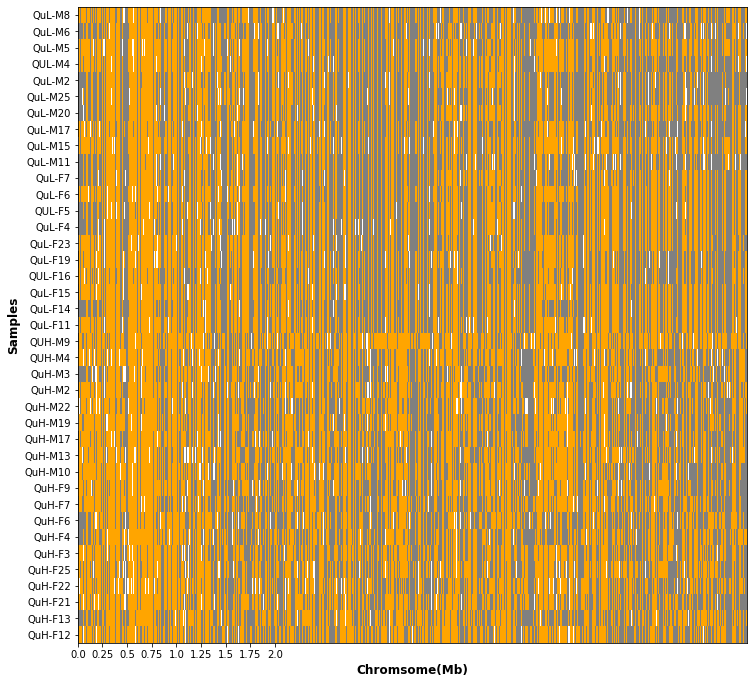

In [10]:
total_list = np.array(total_list)
y = np.arange(1, total_list.shape[1] + 1, 1)  # len = 20
x = np.arange(1, total_list.shape[0] + 1, 1)   # len = 100
cmap = mpl.colors.ListedColormap([
    'white',       # -2, missing
    'orange',       # 0, [0,0]
    "grey",       # 1, [0,1] heterozygosity
    'orange',      # 2, [1,1]
])
fig, ax = plt.subplots(figsize=(12, .3 * total_list.shape[1]))
ax.pcolormesh(x, y, total_list.T, cmap =cmap)
# ax.pcolormesh(genotypeLen, samplesSize, Z=genotype color)
ax.set_yticks(np.arange(1, total_list.shape[1] + 1, 1))
ax.set_xticks(np.arange(0, 22500, 2500))
ax.set_xticklabels(np.arange(0, 2.2500, 0.2500))
ax.set_yticklabels(callset['samples'])
ax.set_xlabel("Chromsome(Mb)", fontweight="bold", fontsize = 12)
ax.set_ylabel("Samples", fontweight="bold", fontsize = 12)


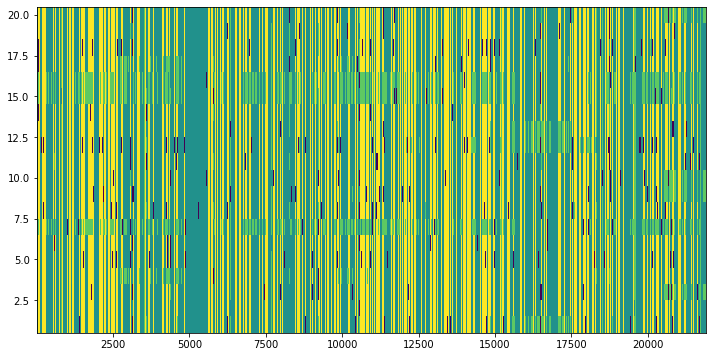

In [204]:
total_list = np.array(total_list)
y = np.arange(1, total_list.shape[1] + 1, 1)  # len = 20
x = np.arange(1, total_list.shape[0] + 1, 1)   # len = 100
cmap = mpl.colors.ListedColormap([
    'grey',      # 0 = undetermined
    'orange',    # 1 = allele inherited from first parental haplotype
    'blue',     # 2 = allele inherited from second parental haplotype
    palette[1],  # 3 = reference allele, also carried by both parental haplotypes
    palette[3],  # 4 = non-reference allele, also carried by both parental haplotypes
    'black',     # 5 = non-parental allele (i.e., Mendelian error)
    palette[5],  # 6 = either or both parental alleles missing
    'white',     # 7 = missing allele
])
fig, ax = plt.subplots(figsize=(12, .3 * total_list.shape[1]))
ax.pcolormesh(x, y, total_list.T)
# ax.pcolormesh(genotypeLen, samplesSize, Z=genotype color)

In [202]:
?ax.pcolormesh

In [ ]:
### fix this tomorrow
def plot_transmission(painting, title=None):
    
    # set figure height depending on number of haplotypes
    fig, ax = plt.subplots(figsize=(12, .2 * painting.shape[1]))
    
    # map painting codes onto colours
    cmap = mpl.colors.ListedColormap([
        'grey',      # 0 = undetermined
        palette[0],  # 1 = allele inherited from first parental haplotype
        palette[2],  # 2 = allele inherited from second parental haplotype
        palette[1],  # 3 = reference allele, also carried by both parental haplotypes
        palette[3],  # 4 = non-reference allele, also carried by both parental haplotypes
        'black',     # 5 = non-parental allele (i.e., Mendelian error)
        palette[5],  # 6 = either or both parental alleles missing
        'white',     # 7 = missing allele
    ])
    
    # plot painting
    # painting.T, transpose  
    ax.pcolormesh(painting.T, cmap=cmap, vmin=0, vmax=7)
    
    # tidy up axes
    ax.set_yticks(np.arange(painting.shape[1]) + .5)
    ax.set_yticklabels(range(painting.shape[1]))
    ax.set_ylabel('Progeny haplotypes')
    ax.set_xlabel('Variants')
    if title:
        ax.set_title(title)

In [109]:
total_list

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]])

# Heterozygosity

In [25]:
#vcf_path = "QUL.LG1.vcf.gz"

In [11]:
# extract genotype data from VCF file 
#callset = allel.read_vcf(vcf_path, region='LR880645.1:18500000-20500000')
# chrom = "LR880645.1" # chromosome 1
# start = 6500000
# end = 8000000
# callset = allel.read_vcf(vcf_path, region='{}:{}-{}'.format(chrom, start, end))

# samples=['QuH-F12', 'QuH-F13', 'QuH-F21', 'QuH-F22', 'QuH-F25', 'QuH-F3',
#        'QuH-F4', 'QuH-F6', 'QuH-F7', 'QuH-F9', 'QuH-M10', 'QuH-M13',
#        'QuH-M17', 'QuH-M19', 'QuH-M22', 'QuH-M2', 'QuH-M3', 'QUH-M4',
#        'QUH-M9']
                        
# samples = ['QuL-F11', 'QuL-F14', 'QuL-F15', 'QUL-F16', 'QuL-F19',
#        'QuL-F23', 'QuL-F4', 'QUL-F5', 'QuL-F6', 'QuL-F7', 'QuL-M11',
#        'QuL-M15', 'QuL-M17', 'QuL-M20', 'QuL-M25', 'QuL-M2', 'QUL-M4',
#        'QuL-M5', 'QuL-M6', 'QuL-M8']
#callset = allel.read_vcf(vcf_path)
# genotype 
g = allel.GenotypeArray(callset['calldata/GT'])
#allel.GenotypeAlleleCounts(vcf_path)

In [12]:
ac = g.count_alleles()[:]
# SNP filtering
flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
gf = g.compress(flt, axis=0)
gn = gf.to_n_alt()
gn

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 2],
       [0, 0, 0, ..., 1, 0, 2],
       [2, 2, 2, ..., 2, 2, 2]], dtype=int8)

In [13]:
gf

<GenotypeArray shape=(63052, 39, 2) dtype=int8>
0/1 0/1 0/1 0/1 0/1 ... 0/1 0/1 0/1 0/1 0/1
0/1 0/1 0/1 ./. 0/1 ... 0/1 ./. 0/1 0/1 0/1
./. 0/1 0/0 0/0 0/0 ... 0/0 0/0 0/0 0/0 0/0
...
0/0 0/0 0/0 0/1 0/0 ... 0/0 1/1 0/1 0/0 1/1
0/0 0/0 0/0 0/1 0/1 ... 0/0 1/1 0/1 0/0 1/1
1/1 1/1 1/1 1/1 1/1 ... 1/1 1/1 1/1 1/1 1/1

In [14]:
coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')

In [15]:
sample_list = []
for i in range(len(callset['samples'])):
    het_count = g[:,i].count_het()
    prop_het_sample = het_count*100 / (end - start)
    sample_list.append([callset['samples'][i], coords1[i][0], coords1[i][1], prop_het_sample])
df = pd.DataFrame(sample_list, columns=["samples",
                                        "PC1", "PC2", "hetero"])

In [19]:
X = df[['PC1']]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
df_cl = X.copy()
# add one more column
df_cl['cluster'] = kmeans.predict(X)
df_cl
df["cluster"] = kmeans.predict(X)
#df["sex"] = ["M"]*10 + ['F'] *10
df["sex"] = ["F"]*10 +  ['M'] *9 + ["F"]*10 +  ['M'] *10 
#df["sex"] = ["F"]*10 + ['M'] *9 
df['pop'] = ['QUH'] * 19 + ['QUL'] * 20
#df['pop'] =  ['QUH'] * 19
df

,samples,PC1,PC2,hetero,cluster,sex,pop
0,QuH-F12,-361.903931,70.560081,0.62430,1,F,QUH
1,QuH-F13,-381.072845,116.587921,0.58292,1,F,QUH
2,QuH-F21,-58.416664,-195.871429,0.39926,2,F,QUH
3,QuH-F22,-55.847080,-133.949875,0.37516,2,F,QUH
4,QuH-F25,-28.644463,-146.619049,0.39056,2,F,QUH
5,QuH-F3,-31.400677,-119.184731,0.38538,2,F,QUH
6,QuH-F4,-239.403961,123.948738,0.53058,1,F,QUH
7,QuH-F6,-342.353302,114.663673,0.54680,1,F,QUH
8,QuH-F7,-1.703602,-19.499018,0.41460,2,F,QUH
9,QuH-F9,-28.750156,-129.918060,0.31938,2,F,QUH


#DA9B4F
#7794C3
#A3B18A


Text(0, 0.5, 'Samples')

<Figure size 3000x2000 with 0 Axes>

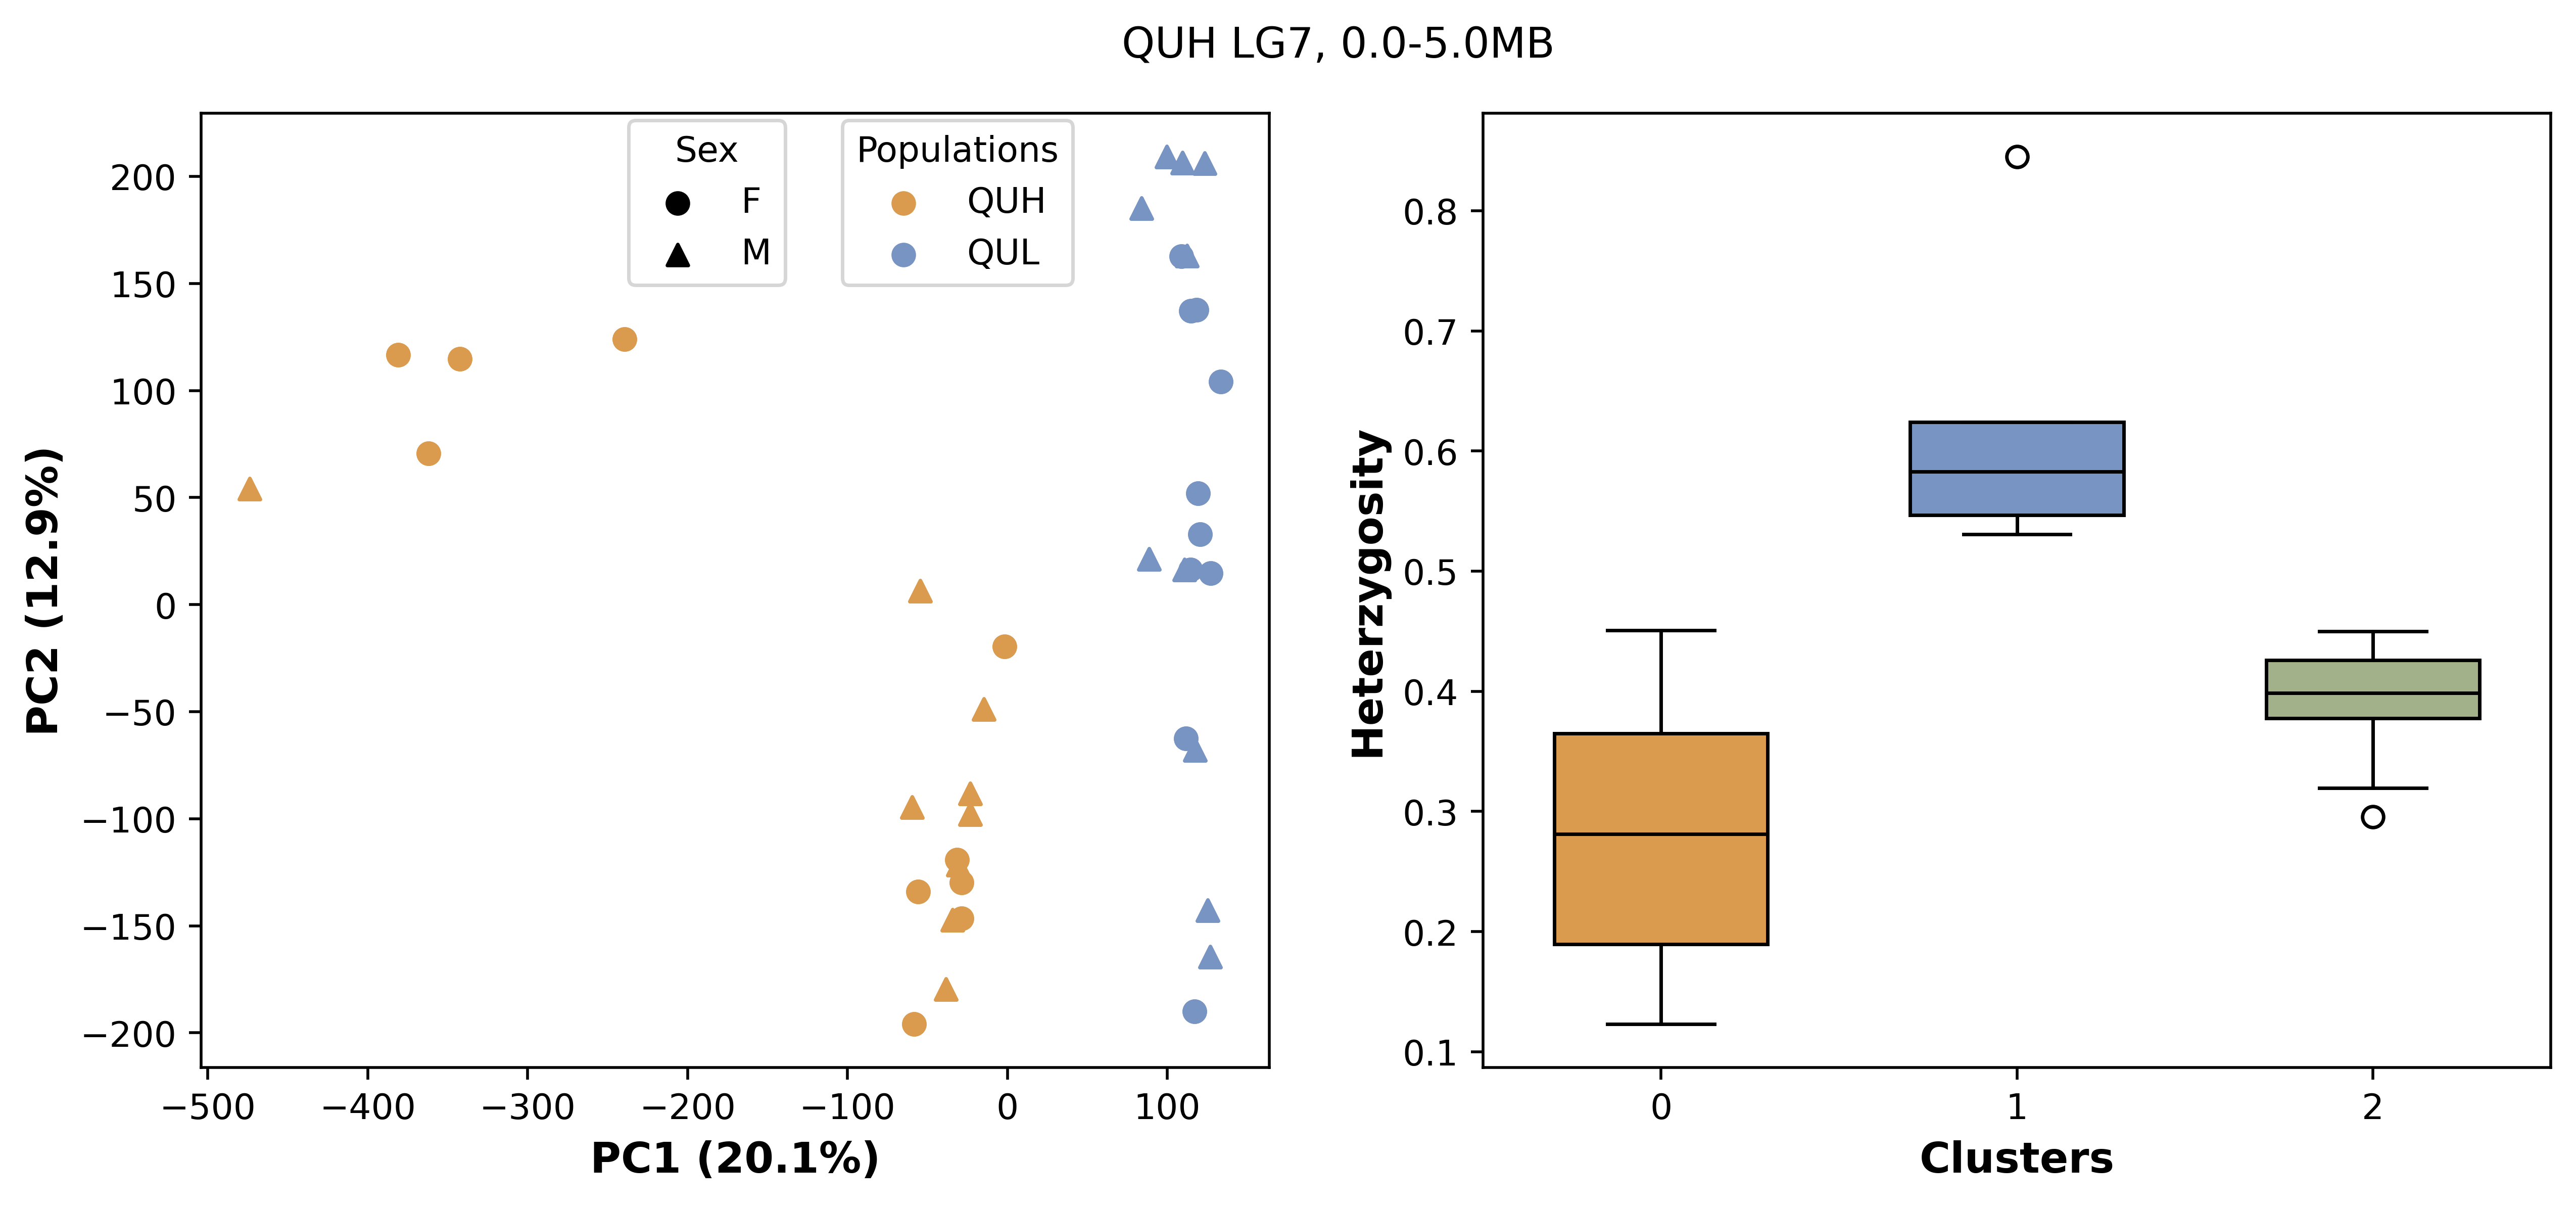

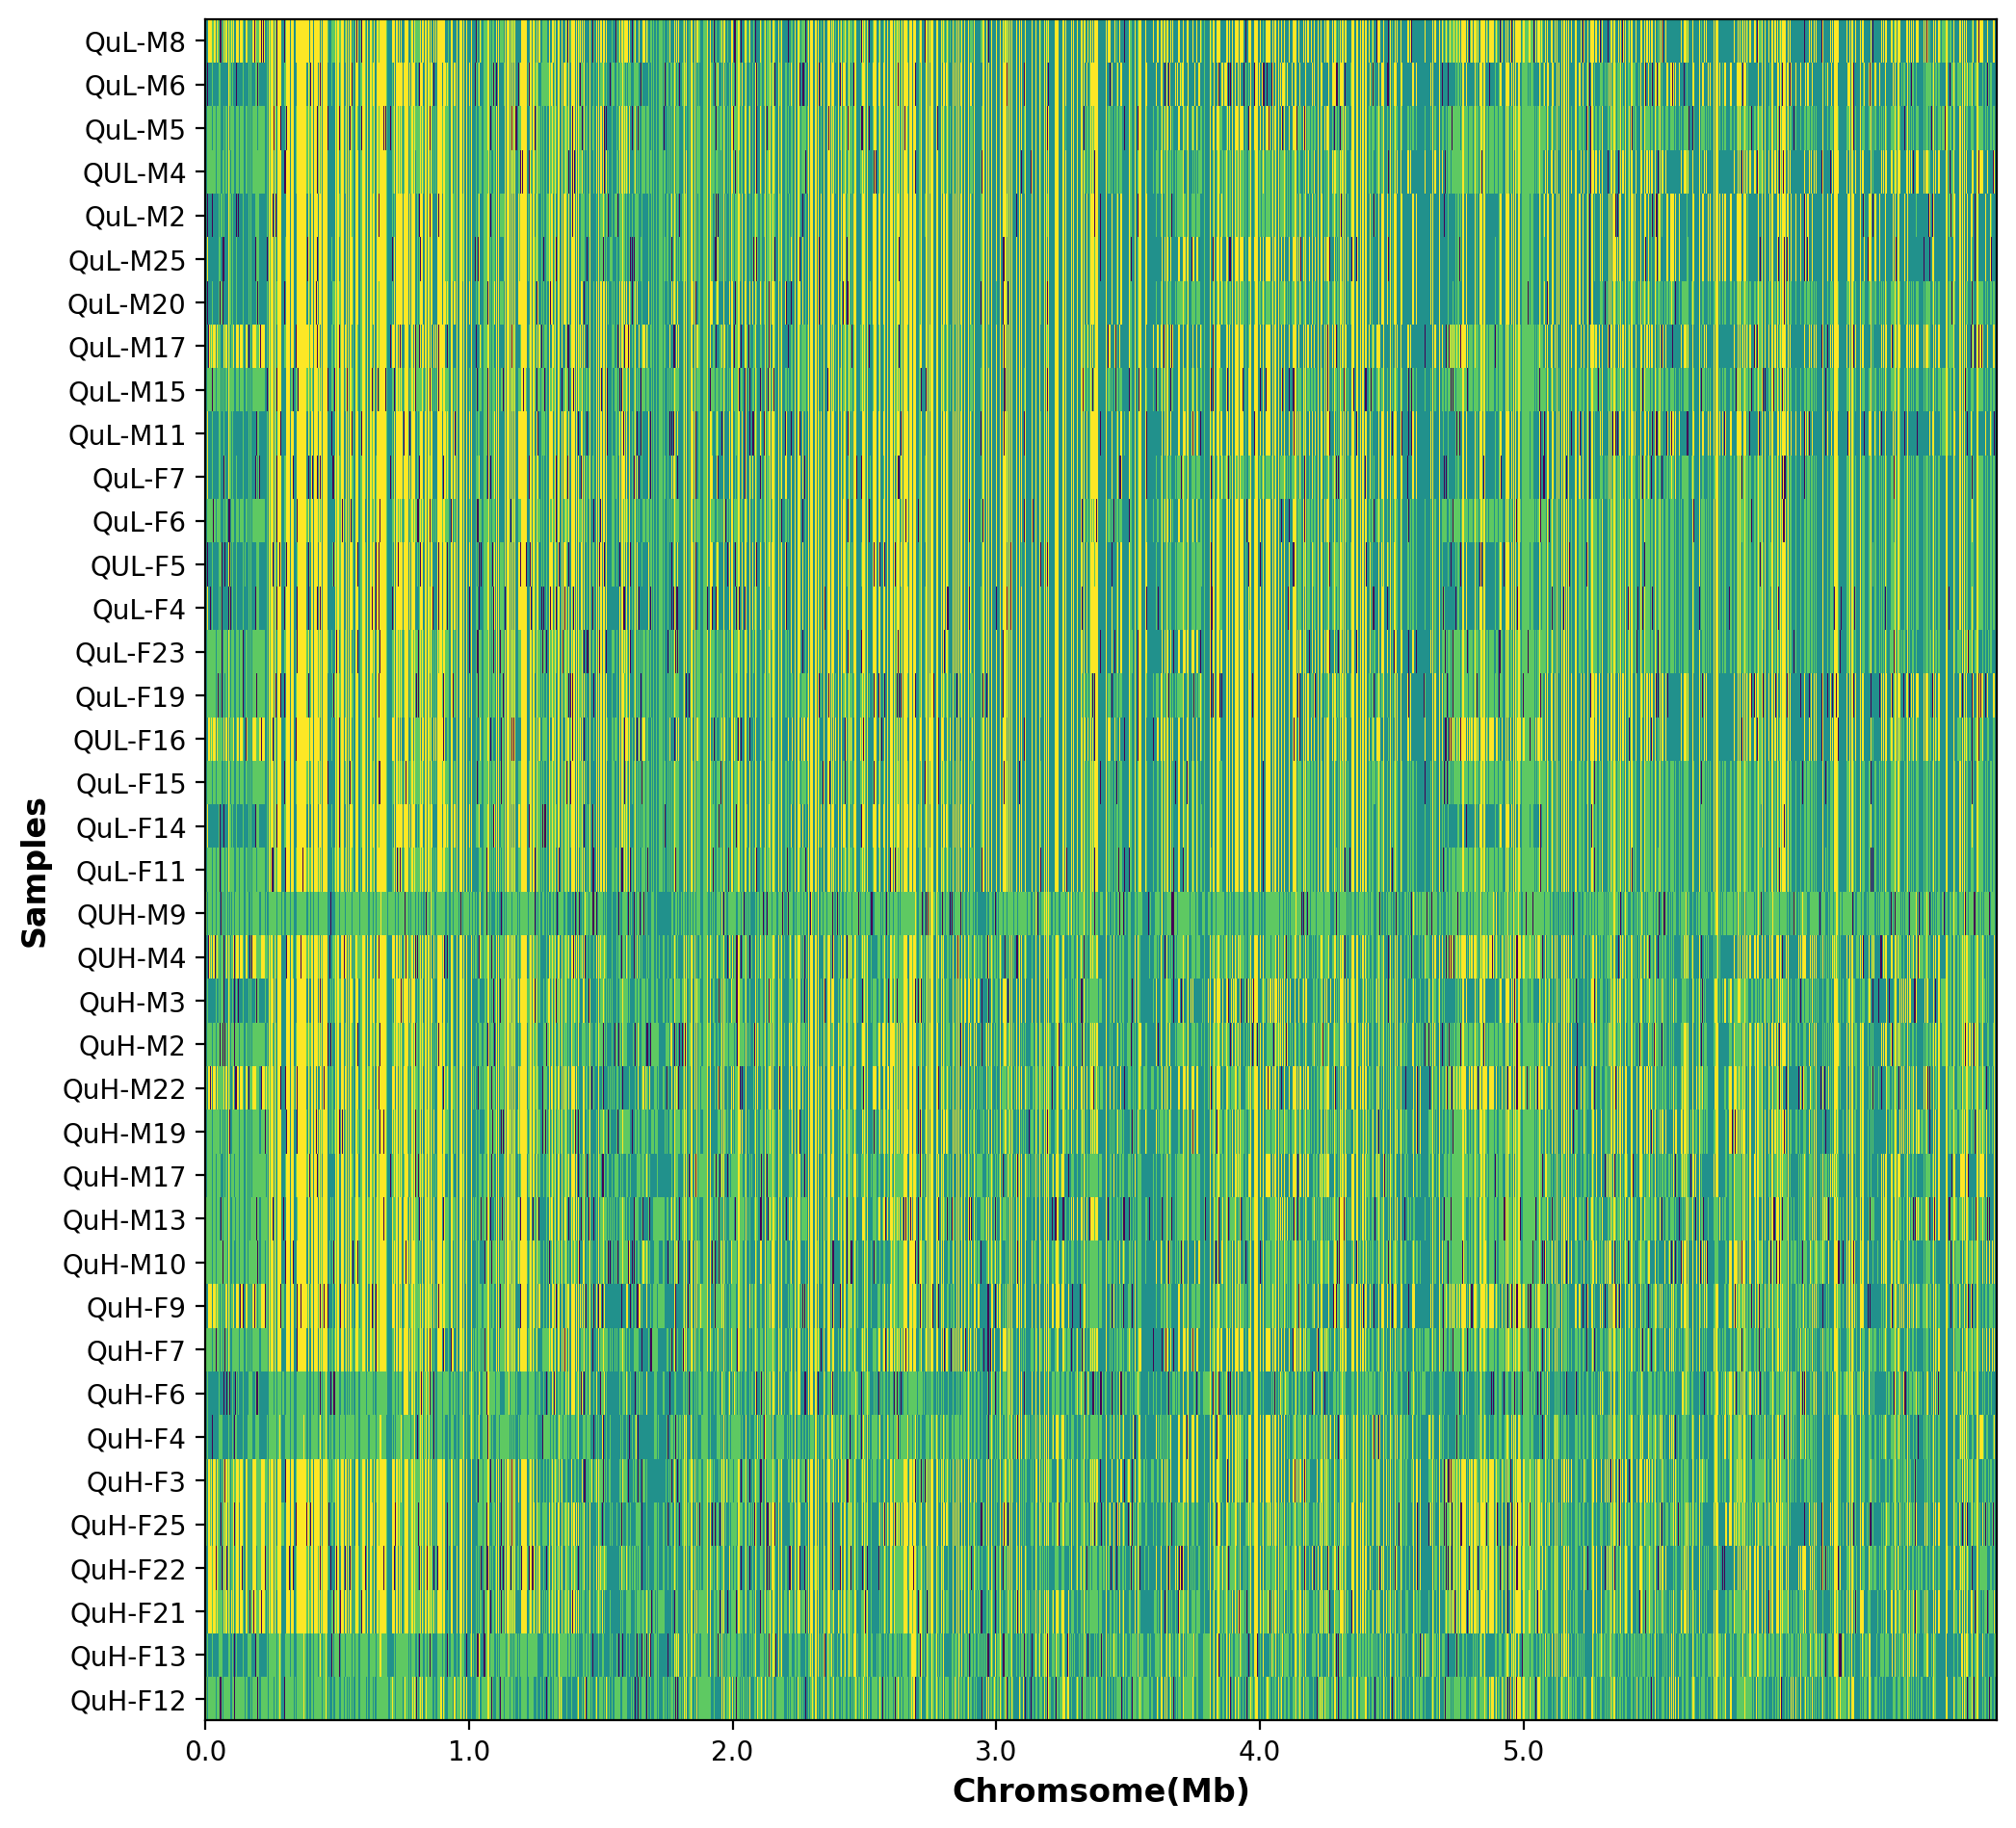

In [29]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.figure(dpi = 500)
# plt.title("LG12, 2-3.5MB")
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi = 500)
fig.suptitle("QUH LG7, {}-{}MB".format(str(int(start)/1000000), str(int(end)/1000000)), y=0.95)

# Read data into a pandas dataframe

#cluster_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
sex_markers = {"F":"o", "M":"^"}
pop_colors = {"QUH": "#DA9B4F", "QUL": '#7794C3'}
#pop_colors = {'QUH':'grey', 'QUL':'orange'}
#pop_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
# Plot the clusters
for pop in pop_colors.keys():
    for s in sex.keys():
        subset = df[(df['pop'] == pop) & (df['sex'] == s)]
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex_markers[s], label=f'{pop}')
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex_markers[s], label=f'{s}')
        
##### previous 
# for pop in cluster_colors.keys():
#     for s in sex.keys():
#         subset = df[(df['cluster'] == int(pop)) & (df['sex'] == s)]
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{pop}')
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{s}')
        
# # Add legend for population
handles, labels = [], []
for pop in pop_colors.keys():
    handles.append(plt.scatter([], [], color=pop_colors[pop], marker='o'))
    labels.append(pop)
first_legend = axs[0].legend(handles, labels, title='Populations', loc=[0.60, 0.82])
axs[0].add_artist(first_legend)

# Add legend for sex
handles, labels = [], []
for s in sex.keys():
    handles.append(plt.scatter([], [], color='black', marker=sex[s]))
    labels.append(s)
axs[0].legend(handles, labels, title='Sex', loc=[0.40, 0.82])

# lables
pc1=0
pc2=1

axs[0].set_xlabel(('PC%s (%.1f%%)' % (pc1+1, model1.explained_variance_ratio_[pc1]*100)), fontsize=12, fontweight="bold")
axs[0].set_ylabel(('PC%s (%.1f%%)' % (pc2+1, model1.explained_variance_ratio_[pc2]*100)), fontsize=12, fontweight="bold")



# Fig 2.1 Define the colors

# plot violin plot for cluster 0
# plot violin plot for cluster 1
# plot violin plot for cluster 0
bplot1 = axs[1].boxplot(df.loc[df["cluster"] == 0, "hetero"], positions=[0], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))
bplot2 = axs[1].boxplot(df.loc[df["cluster"] == 1, "hetero"], positions=[1], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))


bplot3 = axs[1].boxplot(df.loc[df["cluster"] == 2, "hetero"], positions=[2], widths=0.6, 
                        patch_artist=True, medianprops=dict(color="black"))



              
colors = ['#DA9B4F', '#7794C3', '#A3B18A']
#colors = ['#DA9B4F', '#7794C3']
# Set the facecolor for each box
for bplot, color in zip([bplot1, bplot2, bplot3], colors):
    for patch in bplot['boxes']:
        print(color)
        patch.set_color(color)
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
axs[1].set_xticklabels(["0", "1", "2"])

axs[1].set_xlabel("Clusters", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Heterzygosity", fontsize=12, fontweight="bold")


total_list = np.array(total_list)
y = np.arange(1, total_list.shape[1] + 1, 1)  # len = 20
x = np.arange(1, total_list.shape[0] + 1, 1)   # len = 100
cmap = mpl.colors.ListedColormap([
    'white',       # -2, missing
    'orange',       # 0, [0,0]
    "grey",       # 1, [0,1] heterozygosity
    'orange',      # 2, [1,1]
])
fig, ax = plt.subplots(figsize=(12, .3 * total_list.shape[1]),dpi=200)
ax.pcolormesh(x, y, total_list.T)
# ax.pcolormesh(genotypeLen, samplesSize, Z=genotype color)
ax.set_yticks(np.arange(1, total_list.shape[1] + 1, 1))
ax.set_xticks(np.arange(0, 52500, 10000))
ax.set_xticklabels(np.arange(0, 5.2500, 1))
ax.set_yticklabels(callset['samples'])
ax.set_xlabel("Chromsome(Mb)", fontweight="bold", fontsize = 12)
ax.set_ylabel("Samples", fontweight="bold", fontsize = 12)


# interpopulation Fst

In [39]:
genotype_all = allel.GenotypeChunkedArray(callset['calldata/GT'])

In [40]:
df_samples = pd.read_csv("/Users/rainlam/localPCA/Quare.pop", sep="\t")

In [43]:
df_samples.head()
pop1 = 'QuH'
pop2 = 'QuL'
n_samples_pop1 = np.count_nonzero(df_samples.population == pop1)
n_samples_pop2 = np.count_nonzero(df_samples.population == pop2)
print(pop1, n_samples_pop1, pop2, n_samples_pop2)

QuH 19 QuL 20
